# OCR de patentes

Este notebook se construyó **desde cero** para demostrar cómo generar recortes de patentes a partir de las anotaciones de ground truth, aplicar distintos preprocesados y evaluar distintos motores de OCR. Está pensado para un entorno Windows con estructura de carpetas:

- `video01/video.mp4`: vídeo de entrada.
- `video01/vehicles.xml`: anotaciones de vehículos con etiquetas `plate="True"` para las patentes visibles.
- `lanes.xml`: definición de carriles (no se usa aquí).

El flujo general es:

1. Leer el XML y construir un `DataFrame` con las regiones de patente (solo cuando `plate="True"`).
2. Visualizar los recortes de patente para inspeccionar su calidad.
3. Definir varias funciones de preprocesado (incluyendo mejoras como CLAHE y filtrado bilateral) para preparar las imágenes antes de OCR.
4. Ejecutar Tesseract (si está disponible) y EasyOCR sobre los recortes y recopilar los resultados en un DataFrame.
5. Calcular algunas métricas sencillas (porcentaje de textos no vacíos y que cumplen un patrón de matrícula).

Nota: este notebook asume que tienes instalados `opencv-python`, `pandas`, `numpy`, `pytesseract`, `easyocr` y `matplotlib`. Si Tesseract no está instalado o accesible, se omitirá esa parte automáticamente.


In [2]:
from pathlib import Path
import xml.etree.ElementTree as ET
import re

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import pytesseract
import easyocr


In [3]:
# Paths base del proyecto (ajustar si tu estructura es distinta)
ROOT = Path(".")
VIDEO_PATH = ROOT / "video01" / "video.mp4"
XML_VEHICLES = ROOT / "video01" / "vehicles.xml"

OUTPUT_DIR = ROOT / "outputs" / "plates"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("VIDEO_PATH:", VIDEO_PATH.resolve())
print("XML_VEHICLES:", XML_VEHICLES.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

# Configuración opcional de Tesseract (ajustar en tu Windows)
# Ejemplo típico:
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Comprobación rápida (no rompe si no está instalado)
try:
    _ = pytesseract.get_tesseract_version()
    print("Tesseract disponible ✅")
except Exception as e:
    print("Tesseract NO disponible o mal configurado:", e)


VIDEO_PATH: C:\Users\bianc\Vision\tpf\speed\video01\video.mp4
XML_VEHICLES: C:\Users\bianc\Vision\tpf\speed\video01\vehicles.xml
OUTPUT_DIR: C:\Users\bianc\Vision\tpf\speed\outputs\plates
Tesseract NO disponible o mal configurado: tesseract is not installed or it's not in your PATH. See README file for more information.


In [4]:
def load_gt_plates_from_xml(xml_path: Path) -> pd.DataFrame:
    """
    Lee el XML de vehicles y arma un DataFrame con las regiones de patente.

    Parámetros:
      - xml_path: ruta al archivo vehicles.xml.

    Returns:
      - DataFrame con una fila por vehículo con patente visible:
        columnas: frame, lane, x1, y1, x2, y2, w, h,
                  radar_frame_start, radar_frame_end, radar_speed.
    """
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    gtruth = root.find("gtruth")

    rows = []
    for veh in gtruth.findall("vehicle"):
        if veh.get("plate", "False") != "True":
            continue

        iframe = int(veh.get("iframe"))
        lane = int(veh.get("lane"))

        region = veh.find("region")
        x = int(region.get("x"))
        y = int(region.get("y"))
        w = int(region.get("w"))
        h = int(region.get("h"))
        x1, y1 = x, y
        x2, y2 = x + w, y + h

        radar = veh.find("radar")
        if radar is not None:
            radar_frame_start = int(radar.get("frame_start"))
            radar_frame_end = int(radar.get("frame_end"))
            radar_speed = float(radar.get("speed"))
        else:
            radar_frame_start = np.nan
            radar_frame_end = np.nan
            radar_speed = np.nan

        rows.append(
            dict(
                frame=iframe,
                lane=lane,
                x1=x1,
                y1=y1,
                x2=x2,
                y2=y2,
                w=w,
                h=h,
                radar_frame_start=radar_frame_start,
                radar_frame_end=radar_frame_end,
                radar_speed=radar_speed,
            )
        )

    df = pd.DataFrame(rows).reset_index().rename(columns={"index": "idx"})
    return df


In [5]:
df_gt_plates = load_gt_plates_from_xml(XML_VEHICLES)
print("Cantidad de vehículos con patente visible:", len(df_gt_plates))
df_gt_plates.head()


Cantidad de vehículos con patente visible: 115


,idx,frame,lane,x1,y1,x2,y2,w,h,radar_frame_start,radar_frame_end,radar_speed
0,0,58,1,493,696,545,737,52,41,NaN,NaN,NaN
1,1,71,3,1632,930,1738,965,106,35,71.0,111.0,56.65
2,2,107,3,1563,896,1666,923,103,27,107.0,147.0,53.74
3,3,187,2,880,926,988,954,108,28,187.0,227.0,52.13
4,4,245,3,1722,892,1825,924,103,32,245.0,285.0,49.06


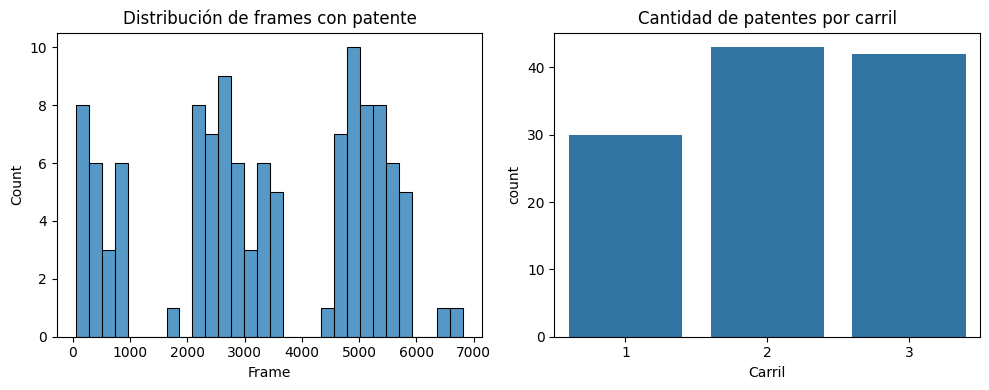

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df_gt_plates["frame"], bins=30, ax=axes[0])
axes[0].set_title("Distribución de frames con patente")
axes[0].set_xlabel("Frame")

sns.countplot(data=df_gt_plates, x="lane", ax=axes[1])
axes[1].set_title("Cantidad de patentes por carril")
axes[1].set_xlabel("Carril")

plt.tight_layout()
plt.show()


In [7]:
def build_plate_crops(df_gt: pd.DataFrame, video_path: Path, margin: int = 4) -> pd.DataFrame:
    """
    Recorta las patentes del video usando el GT de df_gt.

    Parámetros:
      - df_gt: DataFrame con columnas frame, x1, y1, x2, y2, lane, etc.
      - video_path: ruta al archivo de video.
      - margin: margen extra (en píxeles) alrededor de la caja GT.

    Returns:
      - DataFrame df_crops con columnas:
        idx, frame, lane, x1, y1, x2, y2, crop_bgr, radar_speed, ...
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"No se pudo abrir el video: {video_path}")

    crops = []
    current_frame_idx = None
    current_img = None

    for _, row in tqdm(df_gt.iterrows(), total=len(df_gt), desc="Recortando patentes"):
        frame_idx = int(row["frame"])

        # Si cambia el frame, reposicionamos el video
        if current_frame_idx != frame_idx:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret:
                print(f"[WARN] No se pudo leer frame {frame_idx}")
                continue
            current_frame_idx = frame_idx
            current_img = frame

        h_img, w_img = current_img.shape[:2]

        x1 = int(row["x1"])
        y1 = int(row["y1"])
        x2 = int(row["x2"])
        y2 = int(row["y2"])

        # Aplicamos margen y recortamos respetando límites de la imagen
        x1m = max(0, x1 - margin)
        y1m = max(0, y1 - margin)
        x2m = min(w_img - 1, x2 + margin)
        y2m = min(h_img - 1, y2 + margin)

        crop = current_img[y1m:y2m, x1m:x2m].copy()

        crops.append(
            dict(
                idx=row["idx"],
                frame=frame_idx,
                lane=row["lane"],
                x1=x1m,
                y1=y1m,
                x2=x2m,
                y2=y2m,
                w=x2m - x1m,
                h=y2m - y1m,
                radar_speed=row["radar_speed"],
                crop_bgr=crop,
            )
        )

    cap.release()
    df_crops = pd.DataFrame(crops)
    return df_crops


In [8]:
df_crops = build_plate_crops(df_gt_plates, VIDEO_PATH, margin=4)
print("Total de crops de patentes:", len(df_crops))
df_crops.head()


Recortando patentes: 100%|██████████| 115/115 [01:16<00:00,  1.50it/s]


Total de crops de patentes: 115


,idx,frame,lane,x1,y1,x2,y2,w,h,radar_speed,crop_bgr
0,0.0,58,1.0,489,692,549,741,60,49,NaN,"[[[14, 20, 15], [13, 19, 14], [10, 16, 11], [6..."
1,1.0,71,3.0,1628,926,1742,969,114,43,56.65,"[[[94, 88, 76], [94, 88, 76], [94, 88, 76], [9..."
2,2.0,107,3.0,1559,892,1670,927,111,35,53.74,"[[[144, 144, 135], [144, 144, 135], [142, 142,..."
3,3.0,187,2.0,876,922,992,958,116,36,52.13,"[[[150, 150, 134], [150, 150, 134], [150, 149,..."
4,4.0,245,3.0,1718,888,1829,928,111,40,49.06,"[[[68, 70, 63], [67, 69, 62], [66, 68, 61], [6..."


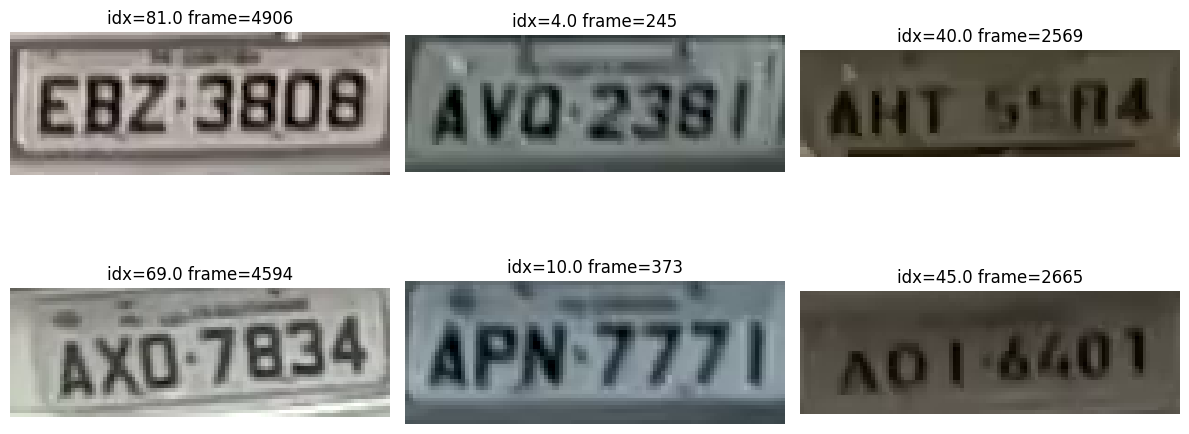

In [9]:
def show_random_crops(df_crops: pd.DataFrame, n: int = 6, seed: int = 0):
    """
    Muestra algunos recortes de patente al azar.
    """
    np.random.seed(seed)
    sample = df_crops.sample(min(n, len(df_crops)))

    cols = 3
    rows = int(np.ceil(len(sample) / cols))

    plt.figure(figsize=(4 * cols, 3 * rows))
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        crop = row["crop_bgr"]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i)
        plt.imshow(crop_rgb)
        plt.axis("off")
        plt.title(f"idx={row['idx']} frame={row['frame']}")
    plt.tight_layout()
    plt.show()


show_random_crops(df_crops, n=6, seed=42)


In [10]:
def preproc_none(crop_bgr: np.ndarray) -> np.ndarray:
    """
    Devuelve el crop tal cual (BGR).
    """
    return crop_bgr


def preproc_adaptive(crop_bgr: np.ndarray, scale: int = 3) -> np.ndarray:
    """
    Gris + resize + blur + threshold adaptativo.
    Devuelve imagen en escala de grises binarizada.
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    gray = cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    th = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2,
    )
    return th


def preproc_morpho(crop_bgr: np.ndarray, scale: int = 3) -> np.ndarray:
    """
    Gris + resize + Otsu + closing morfológico.
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    gray = cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((3, 3), np.uint8)
    closing = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=1)
    return closing


def preproc_clahe(crop_bgr: np.ndarray, scale: int = 3) -> np.ndarray:
    """
    Gris + resize + CLAHE + Otsu.
    Mejora el contraste local antes del umbral.
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    gray = cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(gray)

    _, th = cv2.threshold(eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th


def preproc_bilateral_adaptive(crop_bgr: np.ndarray, scale: int = 3) -> np.ndarray:
    """
    Gris + resize + filtro bilateral + threshold adaptativo.
    Reduce ruido conservando bordes.
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    gray = cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)

    denoise = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    th = cv2.adaptiveThreshold(
        denoise,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        15,
        2,
    )
    return th


PREPROCS = {
    "none": preproc_none,
    "adaptive": preproc_adaptive,
    "morpho": preproc_morpho,
    "clahe": preproc_clahe,
    "bilateral_adaptive": preproc_bilateral_adaptive,
}
list(PREPROCS.keys())


['none', 'adaptive', 'morpho', 'clahe', 'bilateral_adaptive']

In [11]:
# Reader de EasyOCR (idioma inglés, podés agregar otros)
reader = easyocr.Reader(["en"], gpu=False)
print("EasyOCR listo ✅")


def clean_plate_text(text: str) -> str:
    """
    Limpia la salida de OCR dejando sólo A-Z y 0-9 en mayúsculas.
    """
    if text is None:
        return ""
    text = text.upper()
    text = re.sub(r"[^A-Z0-9]", "", text)
    return text

import re

def looks_like_plate(text: str) -> bool:
    """
    Devuelve True si el texto cumple exactamente el formato:
    3 letras (A-Z) seguidas de 4 números (0-9).
    Total: 7 caracteres.
    Ej: ABC1234
    """
    if not text:
        return False

    # Debe tener exactamente 7 caracteres
    if len(text) != 7:
        return False

    # Debe seguir el patrón LLLNNNN
    return bool(re.fullmatch(r"[A-Z]{3}[0-9]{4}", text))



Using CPU. Note: This module is much faster with a GPU.


EasyOCR listo ✅


In [12]:
import pytesseract

# Ruta EXPLÍCITA a tesseract.exe en tu Windows
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print("tesseract_cmd:", pytesseract.pytesseract.tesseract_cmd)

try:
    print("Versión tesseract:", pytesseract.get_tesseract_version())
    print("Tesseract disponible ✅")
except Exception as e:
    print("Error al consultar versión:", e)


tesseract_cmd: C:\Program Files\Tesseract-OCR\tesseract.exe
Versión tesseract: 5.5.0.20241111
Tesseract disponible ✅


In [13]:
def ocr_tesseract(img: np.ndarray, psm: int = 7) -> str:
    """
    Aplica Tesseract sobre la imagen dada (BGR o gris) y devuelve texto limpio.
    """
    if img.ndim == 3:
        # Convertimos a RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img

    config = f"--oem 1 --psm {psm} -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    try:
        raw = pytesseract.image_to_string(img_rgb, config=config)
    except Exception as e:
        print("[WARN] Error llamando a Tesseract:", e)
        raw = ""
    return clean_plate_text(raw)


def ocr_easyocr(img: np.ndarray) -> str:
    """
    Aplica EasyOCR y devuelve texto limpio.
    """
    # EasyOCR acepta BGR o RGB; conviene llevar a RGB
    if img.ndim == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img

    try:
        results = reader.readtext(img_rgb, detail=0)
        raw = "".join(results)
    except Exception as e:
        print("[WARN] Error llamando a EasyOCR:", e)
        raw = ""
    return clean_plate_text(raw)


In [14]:
# Lista de configuraciones a probar
# podés comentar las que no quieras
METHODS = [
    # Tesseract
    dict(name="tess_none", engine="tesseract", preproc="none", psm=7),
    dict(name="tess_adaptive", engine="tesseract", preproc="adaptive", psm=7),
    dict(name="tess_morpho", engine="tesseract", preproc="morpho", psm=7),
    dict(name="tess_clahe", engine="tesseract", preproc="clahe", psm=7),
    dict(name="tess_bilateral_adaptive", engine="tesseract", preproc="bilateral_adaptive", psm=7),

    # EasyOCR
    dict(name="easy_none", engine="easyocr", preproc="none"),
    dict(name="easy_adaptive", engine="easyocr", preproc="adaptive"),
    dict(name="easy_morpho", engine="easyocr", preproc="morpho"),
    dict(name="easy_clahe", engine="easyocr", preproc="clahe"),
    dict(name="easy_bilateral_adaptive", engine="easyocr", preproc="bilateral_adaptive"),
]

METHODS


[{'name': 'tess_none', 'engine': 'tesseract', 'preproc': 'none', 'psm': 7},
 {'name': 'tess_adaptive',
  'engine': 'tesseract',
  'preproc': 'adaptive',
  'psm': 7},
 {'name': 'tess_morpho', 'engine': 'tesseract', 'preproc': 'morpho', 'psm': 7},
 {'name': 'tess_clahe', 'engine': 'tesseract', 'preproc': 'clahe', 'psm': 7},
 {'name': 'tess_bilateral_adaptive',
  'engine': 'tesseract',
  'preproc': 'bilateral_adaptive',
  'psm': 7},
 {'name': 'easy_none', 'engine': 'easyocr', 'preproc': 'none'},
 {'name': 'easy_adaptive', 'engine': 'easyocr', 'preproc': 'adaptive'},
 {'name': 'easy_morpho', 'engine': 'easyocr', 'preproc': 'morpho'},
 {'name': 'easy_clahe', 'engine': 'easyocr', 'preproc': 'clahe'},
 {'name': 'easy_bilateral_adaptive',
  'engine': 'easyocr',
  'preproc': 'bilateral_adaptive'}]

In [15]:
def run_ocr_experiments(df_crops: pd.DataFrame) -> pd.DataFrame:
    """
    Ejecuta todas las configuraciones de METHODS sobre df_crops.

    Returns:
      - DataFrame df_ocr con:
        idx, frame, lane, radar_speed,
        method, engine, preproc,
        text, length, non_empty, looks_plate.
    """
    rows = []

    for cfg in METHODS:
        name = cfg["name"]
        engine = cfg["engine"]
        preproc_name = cfg["preproc"]
        preproc_fn = PREPROCS[preproc_name]

        print(f"==> Ejecutando método: {name}")
        for _, row in tqdm(df_crops.iterrows(), total=len(df_crops), desc=name):
            crop = row["crop_bgr"]
            proc_img = preproc_fn(crop)

            if engine == "tesseract":
                text = ocr_tesseract(proc_img, psm=cfg.get("psm", 7))
            elif engine == "easyocr":
                text = ocr_easyocr(proc_img)
            else:
                raise ValueError(f"Engine desconocido: {engine}")

            clean_text = clean_plate_text(text)
            rows.append(
                dict(
                    idx=row["idx"],
                    frame=row["frame"],
                    lane=row["lane"],
                    radar_speed=row["radar_speed"],
                    method=name,
                    engine=engine,
                    preproc=preproc_name,
                    text=clean_text,
                    length=len(clean_text),
                    non_empty=(clean_text != ""),
                    looks_plate=looks_like_plate(clean_text),
                )
            )

    df_ocr = pd.DataFrame(rows)
    return df_ocr


df_ocr = run_ocr_experiments(df_crops)
print("Total de filas en df_ocr:", len(df_ocr))
df_ocr.head()


==> Ejecutando método: tess_none


tess_none:   0%|          | 0/115 [00:00<?, ?it/s]

tess_none: 100%|██████████| 115/115 [00:36<00:00,  3.18it/s]


==> Ejecutando método: tess_adaptive


tess_adaptive: 100%|██████████| 115/115 [00:34<00:00,  3.30it/s]


...

easy_clahe: 100%|██████████| 115/115 [00:54<00:00,  2.10it/s]


==> Ejecutando método: easy_bilateral_adaptive


easy_bilateral_adaptive: 100%|██████████| 115/115 [00:55<00:00,  2.08it/s]

Total de filas en df_ocr: 1150


,idx,frame,lane,radar_speed,method,engine,preproc,text,length,non_empty,looks_plate
0,0.0,58,1.0,NaN,tess_none,tesseract,none,,0,False,False
1,1.0,71,3.0,56.65,tess_none,tesseract,none,AYD2030,7,True,True
2,2.0,107,3.0,53.74,tess_none,tesseract,none,BAI7690,7,True,True
3,3.0,187,2.0,52.13,tess_none,tesseract,none,ATNBI70,7,True,False
4,4.0,245,3.0,49.06,tess_none,tesseract,none,AV238,5,True,False


In [16]:
def summarize_ocr(df_ocr: pd.DataFrame) -> pd.DataFrame:
    """
    Resume desempeño de OCR por método.
    """
    summary = (
        df_ocr.groupby(["method", "engine", "preproc"])
        .agg(
            n=("text", "size"),
            non_empty_pct=("non_empty", lambda s: 100 * s.mean()),
            looks_plate_pct=("looks_plate", lambda s: 100 * s.mean()),
            avg_len=("length", "mean"),
        )
        .reset_index()
        .sort_values("looks_plate_pct", ascending=False)
    )
    return summary


df_summary = summarize_ocr(df_ocr)
df_summary


,method,engine,preproc,n,non_empty_pct,looks_plate_pct,avg_len
4,easy_none,easyocr,none,115,96.521739,51.304348,6.226087
8,tess_morpho,tesseract,morpho,115,78.260870,42.608696,4.939130
3,easy_morpho,easyocr,morpho,115,89.565217,40.869565,5.652174
9,tess_none,tesseract,none,115,80.000000,40.000000,5.182609
7,tess_clahe,tesseract,clahe,115,71.304348,29.565217,4.521739
2,easy_clahe,easyocr,clahe,115,94.782609,26.956522,5.817391
1,easy_bilateral_adaptive,easyocr,bilateral_adaptive,115,95.652174,12.173913,6.600000
0,easy_adaptive,easyocr,adaptive,115,96.521739,6.956522,6.478261
6,tess_bilateral_adaptive,tesseract,bilateral_adaptive,115,34.782609,6.956522,2.260870
5,tess_adaptive,tesseract,adaptive,115,29.565217,1.739130,1.756522


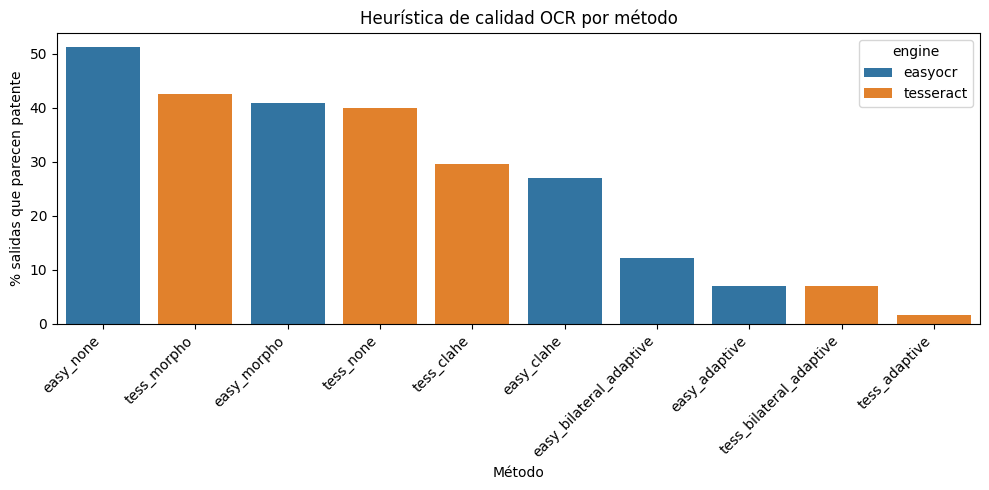

In [17]:
plt.figure(figsize=(10, 5))
order = df_summary.sort_values("looks_plate_pct", ascending=False)["method"]

sns.barplot(
    data=df_summary,
    x="method",
    y="looks_plate_pct",
    hue="engine",
    order=order,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("% salidas que parecen patente")
plt.xlabel("Método")
plt.title("Heurística de calidad OCR por método")
plt.tight_layout()
plt.show()


In [18]:
def show_ocr_examples(
    df_crops: pd.DataFrame,
    df_ocr: pd.DataFrame,
    method: str,
    n: int = 6,
    good: bool = True,
    seed: int = 0,
):
    """
    Muestra ejemplos de OCR para un método dado.

    Parámetros:
      - method: nombre del método (ej: 'easy_clahe').
      - n: cantidad de ejemplos a mostrar.
      - good: True para casos que parecen patente, False para fallos.
    """
    subset = df_ocr[df_ocr["method"] == method].copy()
    subset = subset[subset["looks_plate"] == good]

    if len(subset) == 0:
        print("No hay ejemplos que cumplan esa condición.")
        return

    np.random.seed(seed)
    sample = subset.sample(min(n, len(subset)))

    merged = sample.merge(df_crops[["idx", "frame", "crop_bgr"]], on=["idx", "frame"])

    cols = 3
    rows = int(np.ceil(len(merged) / cols))

    plt.figure(figsize=(4 * cols, 3 * rows))
    for i, (_, row) in enumerate(merged.iterrows(), 1):
        crop_rgb = cv2.cvtColor(row["crop_bgr"], cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i)
        plt.imshow(crop_rgb, cmap="gray")
        plt.axis("off")
        plt.title(f"{row['text']} (frame={row['frame']})")
    plt.suptitle(
        f"{'Buenos' if good else 'Malos'} ejemplos para método {method}",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


Mejor método según la heurística: easy_none


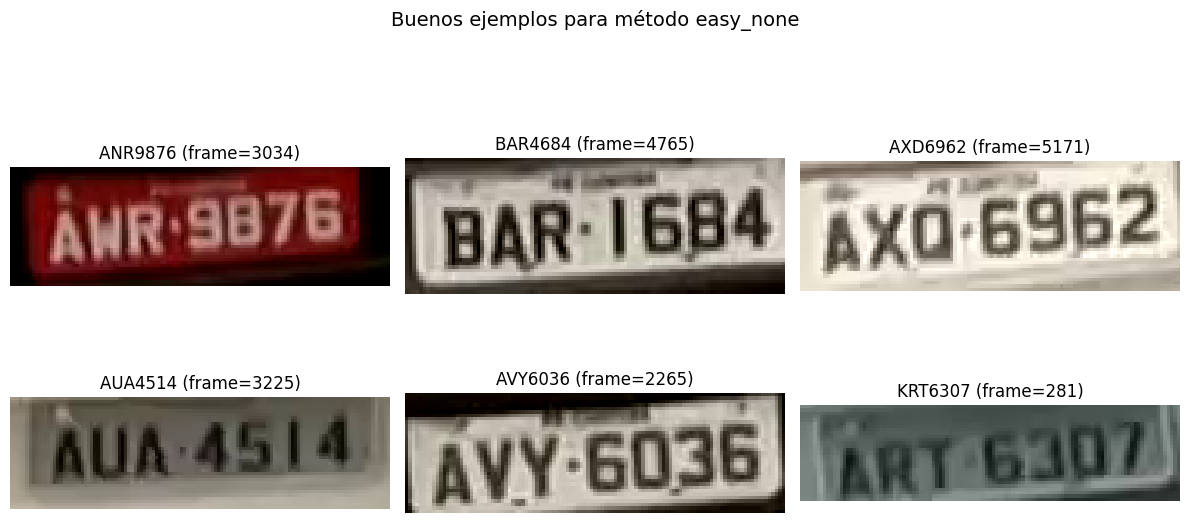

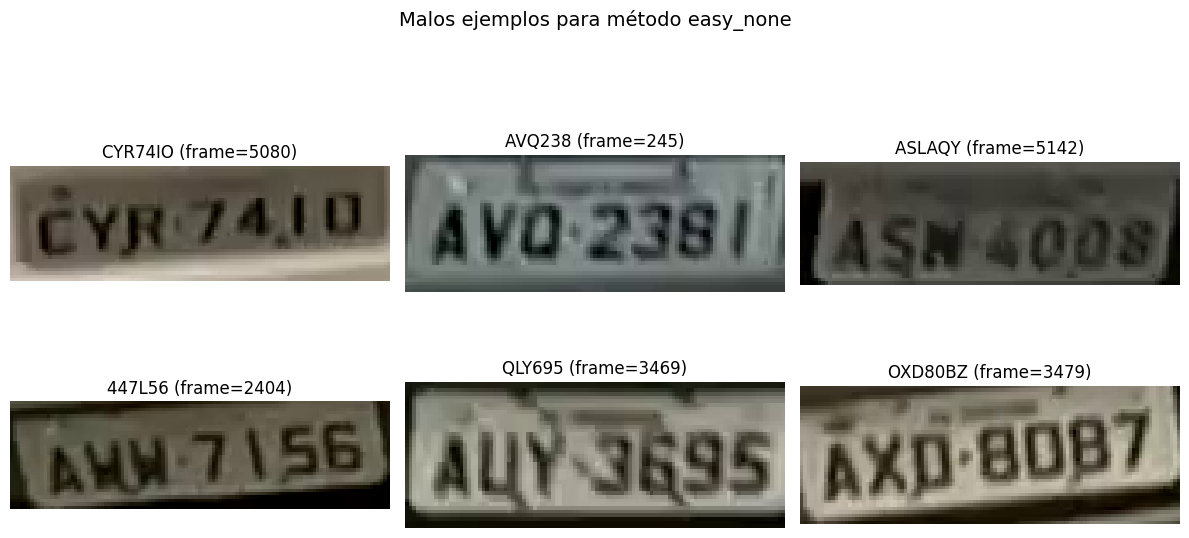

In [19]:
best_method = df_summary.sort_values("looks_plate_pct", ascending=False)["method"].iloc[0]
print("Mejor método según la heurística:", best_method)

# Ejemplos buenos
show_ocr_examples(df_crops, df_ocr, method=best_method, n=6, good=True, seed=0)

# Ejemplos fallidos
show_ocr_examples(df_crops, df_ocr, method=best_method, n=6, good=False, seed=1)


In [20]:
df_gt_plates.to_csv(OUTPUT_DIR / "df_gt_plates.csv", index=False)
df_crops.to_pickle(OUTPUT_DIR / "df_crops.pkl")
df_ocr.to_pickle(OUTPUT_DIR / "df_ocr.pkl")
df_summary.to_csv(OUTPUT_DIR / "df_ocr_summary.csv", index=False)

print("Guardados:")
print(OUTPUT_DIR / "df_gt_plates.csv")
print(OUTPUT_DIR / "df_crops.pkl")
print(OUTPUT_DIR / "df_ocr.pkl")
print(OUTPUT_DIR / "df_ocr_summary.csv")


Guardados:
outputs\plates\df_gt_plates.csv
outputs\plates\df_crops.pkl
outputs\plates\df_ocr.pkl
outputs\plates\df_ocr_summary.csv


In [39]:
# === Nuevos backends OCR: PaddleOCR y fast-plate-ocr ===

from paddleocr import PaddleOCR
from fast_plate_ocr import LicensePlateRecognizer

# PaddleOCR general (OCR inglés)
from paddleocr import PaddleOCR

try:
    paddle_ocr = PaddleOCR(
        use_angle_cls=False,
        lang="en"
    )
except Exception as e:
    print("[WARN] No se pudo inicializar PaddleOCR:", e)
    paddle_ocr = None

print("PaddleOCR disponible:", paddle_ocr is not None)


# fast-plate-ocr: modelo global ligero
try:
    fastplate_model = LicensePlateRecognizer("cct-xs-v1-global-model")
except Exception as e:
    print("[WARN] No se pudo inicializar fast-plate-ocr:", e)
    fastplate_model = None

print("PaddleOCR disponible:", paddle_ocr is not None)
print("fast-plate-ocr disponible:", fastplate_model is not None)


C:\Users\bianc\AppData\Local\Temp\ipykernel_29544\190743956.py:10: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  paddle_ocr = PaddleOCR(


[WARN] No se pudo inicializar PaddleOCR: The pipeline (OCR) does not exist! Please use a pipeline name or a config file path!
PaddleOCR disponible: False
PaddleOCR disponible: False
fast-plate-ocr disponible: True


In [44]:
# Dejamos PaddleOCR desactivado a propósito
paddle_ocr = None
print("PaddleOCR disponible:", paddle_ocr is not None)


PaddleOCR disponible: False


In [45]:
import os
import tempfile

def ocr_paddle(img: np.ndarray) -> str:
    """
    Corre PaddleOCR sobre un recorte de patente y devuelve texto limpio.
    """
    if paddle_ocr is None or img is None:
        return ""

    # PaddleOCR trabaja en RGB
    if len(img.shape) == 2:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    try:
        result = paddle_ocr.ocr(img_rgb, cls=False)
        texts = []
        # result: lista de líneas, cada línea: [ [pts], (text, score) ]
        for line in result:
            if len(line) >= 2 and isinstance(line[1], (list, tuple)):
                texts.append(str(line[1][0]))
        raw = " ".join(texts)
    except Exception as e:
        print("[WARN] Error PaddleOCR:", e)
        raw = ""

    return clean_plate_text(raw)


def ocr_fastplate(img: np.ndarray) -> str:
    """
    Corre fast-plate-ocr sobre un recorte de patente y devuelve texto limpio.
    """
    if fastplate_model is None or img is None:
        return ""

    # Guardar a disco porque fast-plate-ocr espera una ruta de imagen
    if len(img.shape) == 2:
        img_save = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_save = img

    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        tmp_path = tmp.name

    try:
        cv2.imwrite(tmp_path, img_save)
        result = fastplate_model.run(tmp_path)
        if isinstance(result, str):
            raw = result
        elif isinstance(result, dict):
            raw = result.get("plate") or result.get("text") or str(result)
        else:
            raw = str(result)
    except Exception as e:
        print("[WARN] Error fast-plate-ocr:", e)
        raw = ""
    finally:
        try:
            os.remove(tmp_path)
        except OSError:
            pass

    return clean_plate_text(raw)


In [46]:
def run_new_ocr_experiments(
    df_crops: pd.DataFrame,
    preprocs: dict[str, callable],
    engines: tuple[str, ...] = ("paddle", "fastplate"),
    max_samples: int | None = None,
) -> pd.DataFrame:
    """
    Aplica preprocesados y nuevos motores de OCR (Paddle, fast-plate) a cada recorte.

    Devuelve un DataFrame con columnas:
    idx, frame, engine, preproc, method, text, len, non_empty, looks_plate.
    """
    rows = []

    for i, (_, row) in enumerate(df_crops.iterrows()):
        if max_samples is not None and i >= max_samples:
            break

        crop = row["crop_bgr"]

        for pname, pfunc in preprocs.items():
            img_proc = pfunc(crop)

            # PaddleOCR
            if "paddle" in engines and paddle_ocr is not None:
                txt = ocr_paddle(img_proc)
                rows.append({
                    "idx": row["idx"],
                    "frame": row["frame"],
                    "engine": "paddle",
                    "preproc": pname,
                    "method": f"paddle_{pname}",
                    "text": txt,
                    "len": len(txt),
                    "non_empty": len(txt) > 0,
                    "looks_plate": looks_like_plate(txt),
                })

            # fast-plate-ocr
            if "fastplate" in engines and fastplate_model is not None:
                txt = ocr_fastplate(img_proc)
                rows.append({
                    "idx": row["idx"],
                    "frame": row["frame"],
                    "engine": "fastplate",
                    "preproc": pname,
                    "method": f"fastplate_{pname}",
                    "text": txt,
                    "len": len(txt),
                    "non_empty": len(txt) > 0,
                    "looks_plate": looks_like_plate(txt),
                })

    return pd.DataFrame(rows)


# Correr sobre los mismos crops; podés poner max_samples=50 si querés debug rápido
df_ocr_new = run_new_ocr_experiments(
    df_crops,
    PREPROCS,
    engines=("paddle", "fastplate"),
    max_samples=None,
)

df_ocr_new.head()


,idx,frame,engine,preproc,method,text,len,non_empty,looks_plate
0,0.0,58,fastplate,none,fastplate_none,AYH442,6,True,False
1,0.0,58,fastplate,adaptive,fastplate_adaptive,AY88,4,True,False
2,0.0,58,fastplate,morpho,fastplate_morpho,AY1642,6,True,False
3,0.0,58,fastplate,clahe,fastplate_clahe,AYI442,6,True,False
4,0.0,58,fastplate,bilateral_adaptive,fastplate_bilateral_adaptive,AYY322,6,True,False


In [47]:
# Experimentos nuevos SOLO con fast-plate-ocr
df_ocr_new = run_new_ocr_experiments(
    df_crops,
    PREPROCS,
    engines=("fastplate",),   # 👈 sacamos "paddle"
    max_samples=None,         # poné 50 si querés probar rápido
)

df_ocr_new.head()


,idx,frame,engine,preproc,method,text,len,non_empty,looks_plate
0,0.0,58,fastplate,none,fastplate_none,AYH442,6,True,False
1,0.0,58,fastplate,adaptive,fastplate_adaptive,AY88,4,True,False
2,0.0,58,fastplate,morpho,fastplate_morpho,AY1642,6,True,False
3,0.0,58,fastplate,clahe,fastplate_clahe,AYI442,6,True,False
4,0.0,58,fastplate,bilateral_adaptive,fastplate_bilateral_adaptive,AYY322,6,True,False


In [48]:
# Unimos los resultados nuevos con los viejos (si existían)
if "df_ocr" in globals():
    df_ocr_all = pd.concat([df_ocr, df_ocr_new], ignore_index=True)
else:
    df_ocr_all = df_ocr_new

df_ocr = df_ocr_all
print(df_ocr.shape)
df_ocr.head()


(1725, 12)


,idx,frame,lane,radar_speed,method,engine,preproc,text,length,non_empty,looks_plate,len
0,0.0,58,1.0,NaN,tess_none,tesseract,none,,0.0,False,False,NaN
1,1.0,71,3.0,56.65,tess_none,tesseract,none,AYD2030,7.0,True,True,NaN
2,2.0,107,3.0,53.74,tess_none,tesseract,none,BAI7690,7.0,True,True,NaN
3,3.0,187,2.0,52.13,tess_none,tesseract,none,ATNBI70,7.0,True,False,NaN
4,4.0,245,3.0,49.06,tess_none,tesseract,none,AV238,5.0,True,False,NaN


In [49]:
def infer_engine(method: str) -> str:
    m = method.lower()
    if m.startswith("tesseract_") or m.startswith("tess_"):
        return "tesseract"
    if m.startswith("easy_") or m.startswith("easyocr_"):
        return "easyocr"
    if m.startswith("paddle_"):
        return "paddle"
    if m.startswith("fastplate_"):
        return "fastplate"
    return "other"

df_ocr["engine"] = df_ocr["method"].apply(infer_engine)
df_ocr[["method", "engine"]].head()


,method,engine
0,tess_none,tesseract
1,tess_none,tesseract
2,tess_none,tesseract
3,tess_none,tesseract
4,tess_none,tesseract


In [50]:
def summarize_ocr(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df
        .groupby("method")
        .agg(
            total=("idx", "size"),
            non_empty_pct=("non_empty", lambda s: 100 * s.mean()),
            looks_plate_pct=("looks_plate", lambda s: 100 * s.mean()),
            avg_len=("len", "mean"),
        )
        .sort_values("looks_plate_pct", ascending=False)
    )

summary_methods = summarize_ocr(df_ocr)
display(summary_methods.round(2))


summary_engines = (
    df_ocr
    .groupby("engine")
    .agg(
        total=("idx", "size"),
        non_empty_pct=("non_empty", lambda s: 100 * s.mean()),
        looks_plate_pct=("looks_plate", lambda s: 100 * s.mean()),
        avg_len=("len", "mean"),
    )
    .sort_values("looks_plate_pct", ascending=False)
)

display(summary_engines.round(2))


,total,non_empty_pct,looks_plate_pct,avg_len
method,,,,
fastplate_none,115,100.00,93.04,6.93
fastplate_morpho,115,100.00,61.74,6.60
fastplate_bilateral_adaptive,115,100.00,59.13,6.89
fastplate_clahe,115,100.00,59.13,6.62
easy_none,115,96.52,51.30,NaN
tess_morpho,115,78.26,42.61,NaN
fastplate_adaptive,115,100.00,42.61,6.67
easy_morpho,115,89.57,40.87,NaN
tess_none,115,80.00,40.00,NaN


,total,non_empty_pct,looks_plate_pct,avg_len
engine,,,,
fastplate,575,100.00,63.13,6.74
easyocr,575,94.61,27.65,NaN
tesseract,575,58.78,24.17,NaN


In [51]:
def summarize_ocr(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df
        .groupby("method")
        .agg(
            total=("idx", "size"),
            non_empty_pct=("non_empty", lambda s: 100 * s.mean()),
            looks_plate_pct=("looks_plate", lambda s: 100 * s.mean()),
            avg_len=("len", "mean"),
        )
        .sort_values("looks_plate_pct", ascending=False)
    )

summary_methods = summarize_ocr(df_ocr)
display(summary_methods.round(2))


summary_engines = (
    df_ocr
    .groupby("engine")
    .agg(
        total=("idx", "size"),
        non_empty_pct=("non_empty", lambda s: 100 * s.mean()),
        looks_plate_pct=("looks_plate", lambda s: 100 * s.mean()),
        avg_len=("len", "mean"),
    )
    .sort_values("looks_plate_pct", ascending=False)
)

display(summary_engines.round(2))


,total,non_empty_pct,looks_plate_pct,avg_len
method,,,,
fastplate_none,115,100.00,93.04,6.93
fastplate_morpho,115,100.00,61.74,6.60
fastplate_bilateral_adaptive,115,100.00,59.13,6.89
fastplate_clahe,115,100.00,59.13,6.62
easy_none,115,96.52,51.30,NaN
tess_morpho,115,78.26,42.61,NaN
fastplate_adaptive,115,100.00,42.61,6.67
easy_morpho,115,89.57,40.87,NaN
tess_none,115,80.00,40.00,NaN


,total,non_empty_pct,looks_plate_pct,avg_len
engine,,,,
fastplate,575,100.00,63.13,6.74
easyocr,575,94.61,27.65,NaN
tesseract,575,58.78,24.17,NaN


In [52]:
# Recalcular longitud del texto para todos los resultados
df_ocr["len"] = df_ocr["text"].fillna("").astype(str).str.len()

# Volvemos a hacer el resumen
summary_methods = (
    df_ocr
    .groupby("method")
    .agg(
        total=("idx", "size"),
        non_empty_pct=("non_empty", lambda s: 100 * s.mean()),
        looks_plate_pct=("looks_plate", lambda s: 100 * s.mean()),
        avg_len=("len", "mean"),
    )
    .sort_values("looks_plate_pct", ascending=False)
)

display(summary_methods.round(2))


,total,non_empty_pct,looks_plate_pct,avg_len
method,,,,
fastplate_none,115,100.00,93.04,6.93
fastplate_morpho,115,100.00,61.74,6.60
fastplate_bilateral_adaptive,115,100.00,59.13,6.89
fastplate_clahe,115,100.00,59.13,6.62
easy_none,115,96.52,51.30,6.23
tess_morpho,115,78.26,42.61,4.94
fastplate_adaptive,115,100.00,42.61,6.67
easy_morpho,115,89.57,40.87,5.65
tess_none,115,80.00,40.00,5.18


In [53]:
import math
import matplotlib.pyplot as plt

def show_ocr_examples_for_method(
    df_crops: pd.DataFrame,
    df_ocr: pd.DataFrame,
    method: str,
    n: int = 6,
    only_looks_plate: bool = True,
    random_state: int | None = 0,
):
    """
    Muestra 'n' ejemplos de recortes y sus textos para un método de OCR dado.
    Si only_looks_plate=True, se queda sólo con las salidas que parecen patente.
    """
    df_m = df_ocr[df_ocr["method"] == method].copy()
    if only_looks_plate:
        df_m = df_m[df_m["looks_plate"]]

    if df_m.empty:
        print(f"No hay ejemplos para method='{method}' (looks_plate={only_looks_plate}).")
        return

    if n > len(df_m):
        n = len(df_m)

    sample = df_m.sample(n, random_state=random_state)

    # Unimos con df_crops para recuperar la imagen
    df_merge = sample.merge(df_crops[["idx", "crop_bgr"]], on="idx", how="left")

    cols = 3
    rows = math.ceil(n / cols)
    plt.figure(figsize=(4 * cols, 3 * rows))

    for i, row in enumerate(df_merge.itertuples(index=False), start=1):
        img_bgr = row.crop_bgr
        if img_bgr is None:
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"{method}\n'{row.text}'", fontsize=9)

    plt.tight_layout()
    plt.show()


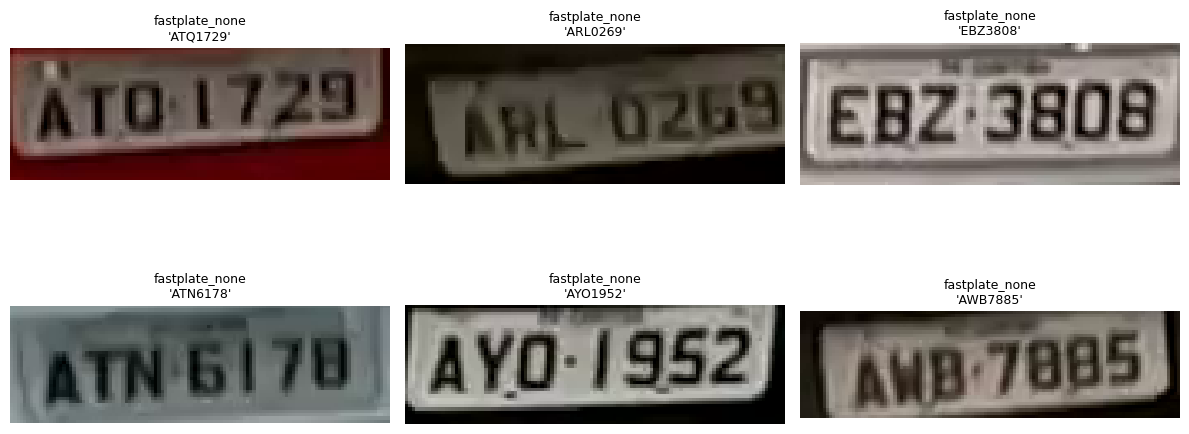

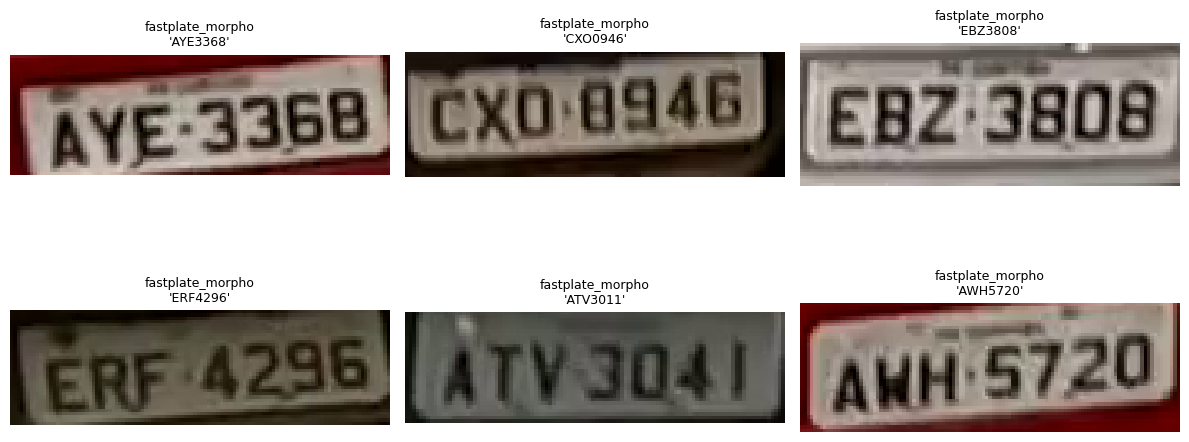

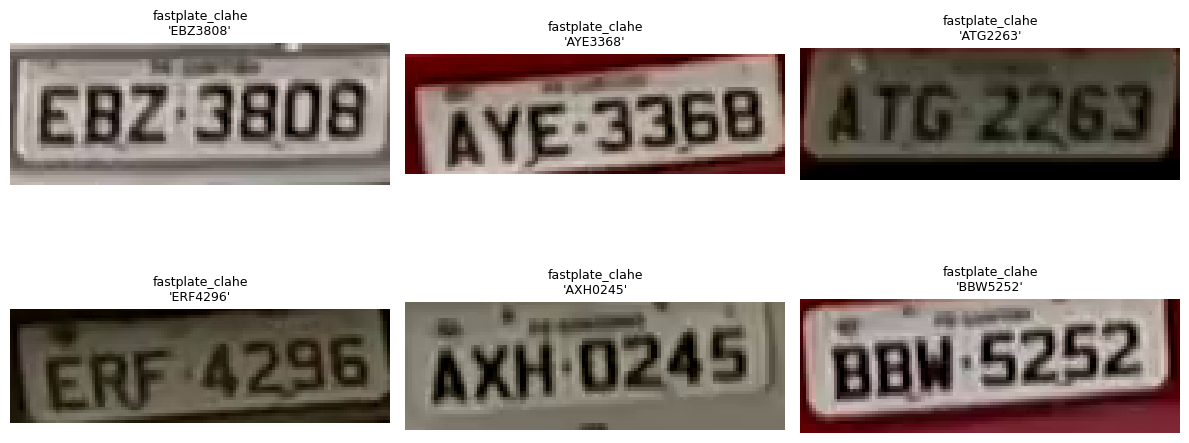

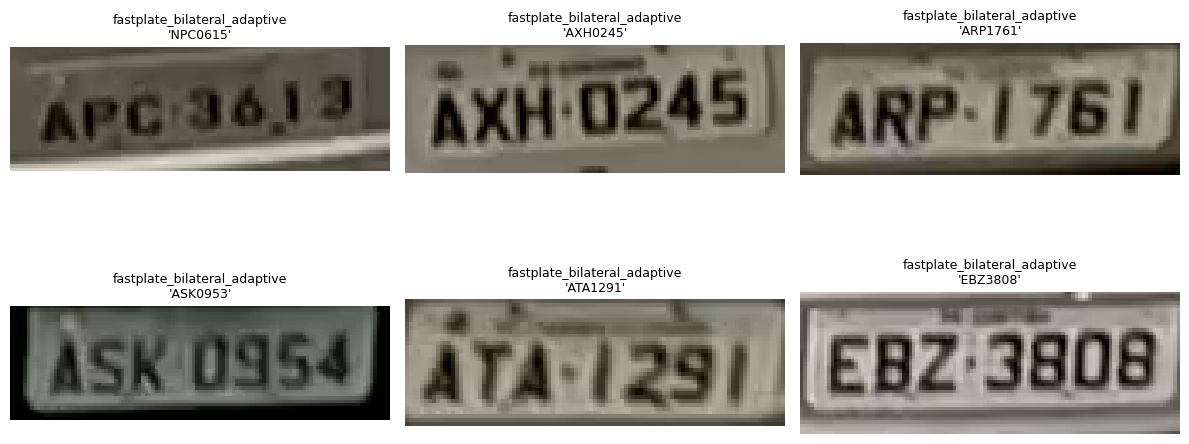

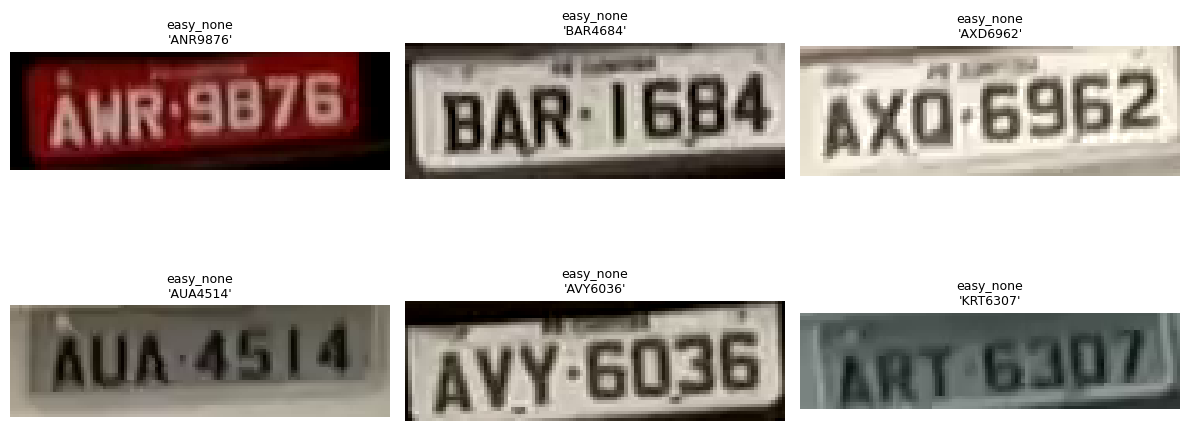

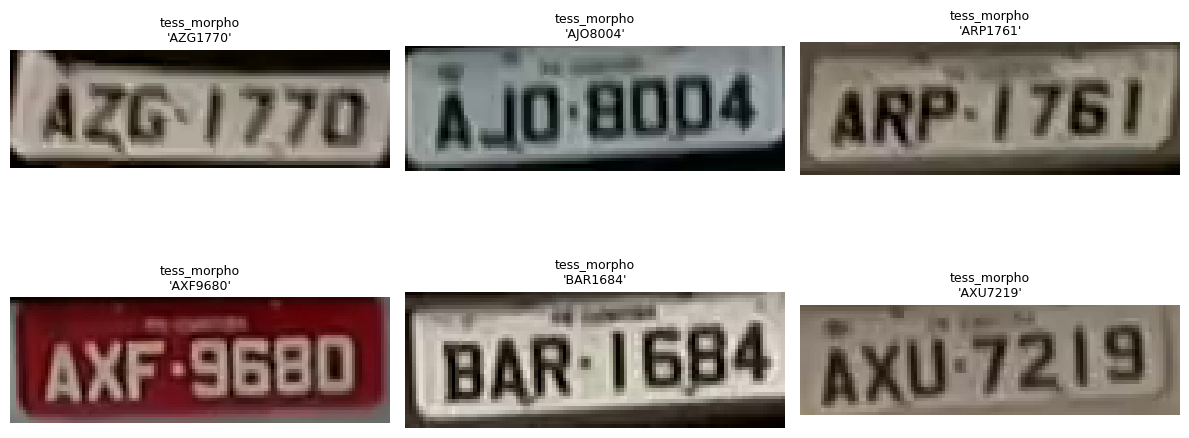

In [54]:
# Fast-plate: mejor crudo
show_ocr_examples_for_method(df_crops, df_ocr, method="fastplate_none", n=6)

# Fast-plate con morpho / clahe / bilateral
show_ocr_examples_for_method(df_crops, df_ocr, method="fastplate_morpho", n=6)
show_ocr_examples_for_method(df_crops, df_ocr, method="fastplate_clahe", n=6)
show_ocr_examples_for_method(df_crops, df_ocr, method="fastplate_bilateral_adaptive", n=6)

# Mejores de easy y tess
show_ocr_examples_for_method(df_crops, df_ocr, method="easy_none", n=6)
show_ocr_examples_for_method(df_crops, df_ocr, method="tess_morpho", n=6)
